In [10]:
# The main aim if this notebook is : To implement Jeffrey Elman’s seminal 1990 experiment ("Finding Structure in Time")

In [11]:
# Import all the necessary libraries :

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [12]:
# Now let's prepare the Toy vocabulary :

sentences = [
    "man chase cat", "cat eat food", "dog chase cat",
    "woman eat food", "man feed dog", "woman feed cat"
]

# Create word mappings
words = list(set(" ".join(sentences).split())) # Fetch all the unique words from the sentences

# Create maps to dynamically fetch convert word to index and vice versa.
word_to_ix = {word: i for i, word in enumerate(words)}
ix_to_word = {i: word for i, word in enumerate(words)}

# Store the vocab size
vocab_size = len(words)

# Generate a continuous stream of text (as Elman did)
corpus = " ".join(sentences * 100).split() # Unlike what we did earlier there is no unique words , there is every word . A continous stream of text.
token_ids = [word_to_ix[w] for w in corpus]  # Fetch the indexes for each word from our dict.

# Prepare inputs (X) and targets (# Y is shifted by 1 step to predict next word)
X_data = torch.tensor(token_ids[:-1]).unsqueeze(0) # Shape: (1, sequence_length)
Y_data = torch.tensor(token_ids[1:]).unsqueeze(0)  # Shape: (1, sequence_length)

In [13]:
# --- 1. MODEL DEFINITION ---
class ElmanRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(ElmanRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn_cell = nn.Linear(embedding_dim + hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, hidden=None):
        batch_size, seq_len = x.size()
        if hidden is None:
            hidden = torch.zeros(batch_size, self.hidden_size).to(x.device)

        embed = self.embedding(x)
        outputs = []
        hidden_states = []  # Track hidden states at every step for plotting

        for t in range(seq_len):
            xt = embed[:, t, :]
            combined = torch.cat((xt, hidden), dim=1)
            hidden = self.sigmoid(self.rnn_cell(combined))

            outputs.append(self.fc(hidden).unsqueeze(1))
            hidden_states.append(hidden.clone().detach())

        outputs = torch.cat(outputs, dim=1)
        return outputs, hidden_states

In [14]:
# --- 2. DATA PREPARATION ---
sentences = [
    "man chase cat", "cat eat food", "dog chase cat",
    "woman eat food", "man feed dog", "woman feed cat"
]
words = list(set(" ".join(sentences).split()))
word_to_ix = {word: i for i, word in enumerate(words)}
ix_to_word = {i: word for i, word in enumerate(words)}
vocab_size = len(words)

# Continuous stream of sentences
corpus = " ".join(sentences * 150).split()
token_ids = [word_to_ix[w] for w in corpus]

X_data = torch.tensor(token_ids[:-1]).unsqueeze(0)
Y_data = torch.tensor(token_ids[1:]).unsqueeze(0)


In [15]:
# --- 3. TRAINING ---
model = ElmanRNN(vocab_size, embedding_dim=10, hidden_size=20)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

print("Training the Elman Network...")
for epoch in range(300):
    model.train()
    optimizer.zero_grad()
    outputs, _ = model(X_data)
    loss = criterion(outputs.view(-1, vocab_size), Y_data.view(-1))
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/300], Loss: {loss.item():.4f}")

Training the Elman Network...
Epoch [100/300], Loss: 1.7537
Epoch [200/300], Loss: 1.3726
Epoch [300/300], Loss: 1.1013


In [16]:
# --- 4. EXTRACT HIDDEN STATES FOR PLOTTING ---
model.eval()
with torch.no_grad():
    # Pass data through the trained model to gather contextual hidden states
    _, hidden_states_list = model(X_data)

    # Shape of hidden_states_list is (seq_len, batch_size=1, hidden_size)
    # Convert to a numpy array of shape (seq_len, hidden_size)
    hidden_matrix = torch.cat(hidden_states_list, dim=0).cpu().numpy()

# Aggregate hidden vectors by word token to find the average representation
word_hidden_vectors = {word: [] for word in words}

# Map each hidden state step back to the specific input word that generated it
for idx, word_id in enumerate(token_ids[:-1]):
    word = ix_to_word[word_id]
    word_hidden_vectors[word].append(hidden_matrix[idx])

# Calculate the mean hidden state vector for each word in the vocabulary
mean_vectors = []
labels = []
for word, vectors in word_hidden_vectors.items():
    if len(vectors) > 0:
        mean_vectors.append(np.mean(vectors, axis=0))
        labels.append(word)

mean_vectors = np.array(mean_vectors)

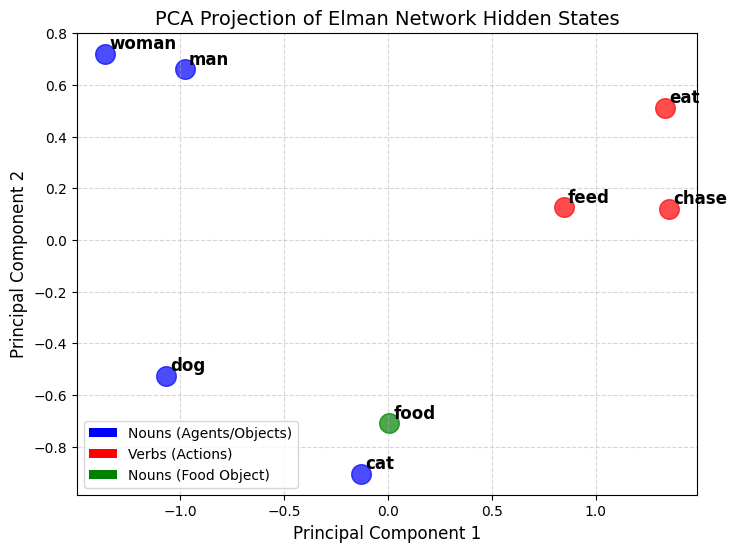

In [17]:
# --- 5. DIMENSIONALITY REDUCTION & PLOT ---
# Reduce 20-dimensional hidden states down to 2 dimensions for visual mapping
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(mean_vectors)

# Define color categories to visually separate syntax structures
# Nouns = Blue, Verbs = Red, Food (Object) = Green
colors = {
    'man': 'blue', 'woman': 'blue', 'dog': 'blue', 'cat': 'blue',
    'chase': 'red', 'eat': 'red', 'feed': 'red',
    'food': 'green'
}

plt.figure(figsize=(8, 6))
for i, label in enumerate(labels):
    x, y = reduced_vectors[i, 0], reduced_vectors[i, 1]
    color = colors.get(label, 'black')
    plt.scatter(x, y, color=color, s=200, alpha=0.7)
    plt.text(x + 0.02, y + 0.02, label, fontsize=12, weight='bold')

plt.title("PCA Projection of Elman Network Hidden States", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Add a legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Nouns (Agents/Objects)'),
    Patch(facecolor='red', label='Verbs (Actions)'),
    Patch(facecolor='green', label='Nouns (Food Object)')
]
plt.legend(handles=legend_elements, loc='best')
plt.show()